#Benchmark of SRPose vs classical geometry pipelines

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd drive/MyDrive/Internship/SRPose-main

/content/drive/MyDrive/Internship/SRPose-main


In [3]:
import torch
import numpy as np
from scipy.spatial.transform import Rotation as R, Slerp
from pathlib import Path
import matplotlib.pyplot as plt
import os

In [4]:
# !pip uninstall -y torch torchvision torchaudio

GPU version:

In [5]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [4]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch version: 2.11.0+cu128
cuda available: True
GPU: Tesla T4


In [7]:
!pip install -r requirements.txt

  Cloning https://github.com/cvg/LightGlue (to revision main) to /tmp/pip-install-1rjtfjh0/lightglue_e6337aae78744482ad4e57eabde5f85d
  Running command git clone --filter=blob:none --quiet https://github.com/cvg/LightGlue /tmp/pip-install-1rjtfjh0/lightglue_e6337aae78744482ad4e57eabde5f85d
  Resolved https://github.com/cvg/LightGlue to commit eb42fee2d71449efb0aa5c10549752b5d75384d8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━

In [5]:
import cv2
from model.pl_trainer import PL_RelPose, keypoint_dict

/usr/local/lib/python3.12/dist-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [ ]:
# !mkdir checkpoints

In [ ]:
# !mkdir data

i downloaded the scannet checkpoint from: https://drive.google.com/drive/folders/1bBlds3UX7-XDCevbIl4bnnywvWzzP5nN and stored it in checkpoints folder

inside data, i created a scannet folder and put the test and indices of the scannet dataset downloaded from:

using the pretrained ScanNet checkpoint to make predictions

In [7]:
torch.serialization.add_safe_globals([
    getattr,
    torch.optim.lr_scheduler.OneCycleLR
])

ckpt = "checkpoints/scannet.ckpt"

device = "cuda" if torch.cuda.is_available() else "cpu"


model = PL_RelPose.load_from_checkpoint(
    ckpt,
    map_location=device,
)

model.eval()
model.to(device);

In [9]:
print(model.hparams)

"epochs":        500
"features":      superpoint
"lr":            0.0001
"n_layers":      6
"num_heads":     4
"num_keypoints": 1024
"pct_start":     0.3
"task":          scene


should see {
    'task': 'scene',
    'features': 'superpoint',
    ...
}

In [10]:
def load_image(path):
    img = cv2.imread(path)
    if img.shape[:2] != (480, 640):
      img = cv2.resize(img, (640, 480))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = torch.from_numpy(img).permute(2,0,1).float() / 255.
    return img

Dataset: TUM RGB-D Dataset

Intrinsics: fx=517.3, fy=516.5,	cx=318.6,	cy=255.3

TUM Dataset: i downloaded the fr1/xyz dataset which contains 798 RGB images alongside their absolute camera pose in the world frame: each image has its own camera pose in the world coordinate system

So, what we did was: we took 2 consecutive frames and fed them to SRPose. SRPose returned the relative pose between the 2 cameras of the 2 images (T1->2).

Then, to compare that, we get the ground truth relative pose by computing T1->2=T2​.T1^-1​, where T1 and T2 are the absolute camera poses of frame 1 and 2 respectively, provided by TUM

In [11]:
def infer_pair(img0_path, img1_path, K0, K1):
    img0 = load_image(img0_path)
    img1 = load_image(img1_path)

    images = torch.stack([img0, img1], dim=0).unsqueeze(0)
    intrinsics = torch.stack([K0, K1], dim=0).unsqueeze(0)

    data = {
        "images": images,
        "intrinsics": intrinsics,
    }

    with torch.no_grad():
        R, t, _, _, _ = model.predict_one_data(
            data,
            device=device
        )

    return R.cpu().numpy(), t.cpu().numpy()

Error Computing

In [12]:
def rotation_error(R_gt, R_pred):
    R_diff = R_gt.T @ R_pred
    angle = np.arccos(np.clip((np.trace(R_diff) - 1) / 2, -1.0, 1.0))
    return np.degrees(angle)

def translation_error(t_gt, t_pred):
    t_gt = t_gt / np.linalg.norm(t_gt)
    t_pred = t_pred / np.linalg.norm(t_pred)
    cos_angle = np.clip(np.dot(t_gt, t_pred), -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))

batch evaluation: we choose to test the model on 100 image pairs from the TUM dataset

The RGB-D Camera (Kinect): Captures color and depth frames at roughly 30 Hz (30 frames per second).

The Motion Capture System (OptiTrack): Captures the true 3D position and orientation of the camera at a much higher frequency (usually 100 Hz to 200 Hz).

Because these two systems run on independent internal clocks and trigger at different intervals, their timestamps will never align perfectly down to the microsecond

In [13]:
# from https://github.com/tgale96/tum-rgbd-associate/blob/master/associate.py
def associate(first_list, second_list, max_diff):
    """
    Associate two dictionaries of (stamp,data). As the time stamps never match exactly,
    we aim to find the closest match for every input tuple.

    Input:
    first_list -- first dictionary of (stamp,data) tuples
    second_list -- second dictionary of (stamp,data) tuples
    max_diff -- search radius for candidate generation

    Output:
    matches -- list of matched tuples ((stamp1,data1),(stamp2,data2))"""

    # We need the keys to be sorted for this to work
    first_keys = list(first_list.keys())
    second_keys = list(second_list.keys())
    first_keys.sort()
    second_keys.sort()

    matches = []
    b_idx = 0
    for a_idx in range(0, len(first_keys)):
        # exit if we go out of range
        if b_idx >= len(second_keys):
            break

        a_val = first_keys[a_idx]
        while second_keys[b_idx] < a_val:
            b_idx += 1

        diff1 = abs(second_keys[b_idx] - a_val)
        diff2 = abs(second_keys[b_idx-1] - a_val)
        if diff1 < diff2 and diff1 <= max_diff:
            matches.append((a_val, second_keys[b_idx]))
            b_idx += 2
        elif diff2 <= diff1 and diff2 <= max_diff:
            matches.append((a_val, second_keys[b_idx-1]))
            b_idx += 1

    return matches

In [14]:
def read_file_to_dict(filename, is_gt=False):
    """
    Reads a TUM RGB-D file into a dictionary mapping float timestamps to data.
    """
    data_dict = {}
    with open(filename, 'r') as f:
        for line in f:
            # Skip comments and empty lines
            if line.startswith('#') or not line.strip():
                continue

            # Split line by whitespace
            parts = line.strip().split()

            # The first item is always the timestamp
            timestamp = float(parts[0])

            if is_gt:
                # For groundtruth: parse tx, ty, tz, qx, qy, qz, qw as floats
                data = [float(x) for x in parts[1:]]
            else:
                # For rgb: the data is just the image file path string
                data = parts[1]

            data_dict[timestamp] = data

    return data_dict

In [15]:
def pose_to_T(tx, ty, tz, qx, qy, qz, qw):
  """
  Takes the ground truth translation and rotation of an absolute pose, converts from quaternion to rotation matrix and returns the transformation matrix [R|t]
  """
  T = np.eye(4)
  T[:3, :3] = R.from_quat([qx, qy, qz, qw]).as_matrix()
  T[:3, 3] = [tx, ty, tz]
  return T

In [16]:
dataset_path = "../dataset-TUM/"

# Parsing both files into dictionaries
rgb_list = read_file_to_dict("../dataset-TUM/rgb.txt", is_gt=False)
gt_list = read_file_to_dict("../dataset-TUM/groundtruth.txt", is_gt=True)

# max difference threshold (e.g., 0.02 seconds)
max_diff = 0.02

# Calling the association function
# (Note: Passing rgb as first_list ensures we find a ground-truth pose for each image)
raw_matches = associate(rgb_list, gt_list, max_diff)

# removing from the matches the rgb file names that dont have an image correspondent in the rgb folder
matches = []
for rgb_stamp, gt_stamp in raw_matches:
    # getting the relative path (ex: 'rgb/1305031102.175304.png')
    img_rel_path = rgb_list[rgb_stamp]

    # combining with dataset base path to get the absolute path
    full_img_path = os.path.join(dataset_path, img_rel_path)

    # only keeping the match if the file exists
    if os.path.exists(full_img_path):
        matches.append((rgb_stamp, gt_stamp))

# printing stats to see how many were removed
print(f"Total raw matches: {len(raw_matches)}")
print(f"Valid matches (images exist): {len(matches)}")
print(f"Filtered out {len(raw_matches) - len(matches)} missing images.")

# Printing the first 5 matches to verify
for rgb_stamp, gt_stamp in matches[:5]:
    print(f"RGB Image: {rgb_list[rgb_stamp]} matched with GT Pose: {gt_list[gt_stamp]}")

Total raw matches: 796
Valid matches (images exist): 796
Filtered out 0 missing images.
RGB Image: rgb/1305031102.175304.png matched with GT Pose: [1.3405, 0.6266, 1.6575, 0.6574, 0.6126, -0.2949, -0.3248]
RGB Image: rgb/1305031102.211214.png matched with GT Pose: [1.3303, 0.6256, 1.6464, 0.6579, 0.6161, -0.2932, -0.3189]
RGB Image: rgb/1305031102.243211.png matched with GT Pose: [1.323, 0.6252, 1.6384, 0.659, 0.6186, -0.2912, -0.3135]
RGB Image: rgb/1305031102.275326.png matched with GT Pose: [1.316, 0.6254, 1.6302, 0.6609, 0.6199, -0.2893, -0.3086]
RGB Image: rgb/1305031102.311267.png matched with GT Pose: [1.3066, 0.6256, 1.6196, 0.6621, 0.6205, -0.2892, -0.305]


The Threshold: A max difference of 0.02 seconds (20 milliseconds) is standard because the RGB camera captures a frame every ~33ms, meaning the closest pose should never be further than ~16.5ms away.

Now we loop through the rgb list and apply the SRPose model on two consecutive frames

In [17]:
# our intrinsic K based on the documentation provided by TUM RGB-D Dataset: https://cvg.cit.tum.de/data/datasets/rgbd-dataset/file_formats#intrinsic_camera_calibration_of_the_kinect
K = torch.tensor([
    [517.3,   0.0, 318.6],
    [  0.0, 516.5, 255.3],
    [  0.0,   0.0,   1.0]
], dtype=torch.float32)

stride = 2 # this will take every frame and every second consecutive frame (frame 0 and frame 2 for example) as image pairs

# this is to store the rotation and translation errors between the predicted and the ground truth R and t
rot_errors = []
trans_errors = []

for i in range(len(matches) - stride):
  # extracting the matches
  match1 = matches[i]
  match2 = matches[i + stride]

  # extracting the time stamps
  rgb_stamp1, gt_stamp1 = match1
  rgb_stamp2, gt_stamp2 = match2

  # getting the relative image file paths from the rgb_list dictionary
  img1_rel_path = rgb_list[rgb_stamp1]
  img2_rel_path = rgb_list[rgb_stamp2]

  # constructing full absolute paths
  img1_path = os.path.join(dataset_path, img1_rel_path)
  img2_path = os.path.join(dataset_path, img2_rel_path)

  # running the model
  print("Running on: ", img1_path, " and ", img2_path)
  R_pred, t_pred = infer_pair(img1_path, img2_path, K, K)

  # extracting ground truth components
  tx1, ty1, tz1, qx1, qy1, qz1, qw1 = gt_list[gt_stamp1]
  tx2, ty2, tz2, qx2, qy2, qz2, qw2 = gt_list[gt_stamp2]

  # computing transformation matrices for both frames
  T1 = pose_to_T(tx1, ty1, tz1, qx1, qy1, qz1, qw1)
  T2 = pose_to_T(tx2, ty2, tz2, qx2, qy2, qz2, qw2)

  # computing relative transformation between the 2 frames
  # Trel=T2^-1 * T1
  T_rel = np.linalg.inv(T2) @ T1

  #extracting the relative ground truth R and t
  R_gt = T_rel[:3, :3]
  t_gt = T_rel[:3, 3]

  # appending to the list of rotation and translation errors which we compute between the predicted and the ground truth
  rot_errors.append(rotation_error(R_gt, R_pred))
  trans_errors.append(translation_error(t_gt, t_pred))



Running on:  ../dataset-TUM/rgb/1305031102.175304.png  and  ../dataset-TUM/rgb/1305031102.243211.png
Running on:  ../dataset-TUM/rgb/1305031102.211214.png  and  ../dataset-TUM/rgb/1305031102.275326.png
Running on:  ../dataset-TUM/rgb/1305031102.243211.png  and  ../dataset-TUM/rgb/1305031102.311267.png
Running on:  ../dataset-TUM/rgb/1305031102.275326.png  and  ../dataset-TUM/rgb/1305031102.343233.png
Running on:  ../dataset-TUM/rgb/1305031102.311267.png  and  ../dataset-TUM/rgb/1305031102.375329.png
Running on:  ../dataset-TUM/rgb/1305031102.343233.png  and  ../dataset-TUM/rgb/1305031102.411258.png
Running on:  ../dataset-TUM/rgb/1305031102.375329.png  and  ../dataset-TUM/rgb/1305031102.443271.png
Running on:  ../dataset-TUM/rgb/1305031102.411258.png  and  ../dataset-TUM/rgb/1305031102.475318.png
Running on:  ../dataset-TUM/rgb/1305031102.443271.png  and  ../dataset-TUM/rgb/1305031102.511219.png
Running on:  ../dataset-TUM/rgb/1305031102.475318.png  and  ../dataset-TUM/rgb/1305031102.5

Results

In [18]:
print("Mean rotation error:", np.mean(rot_errors))
print("Median rotation error:", np.median(rot_errors))

print("Mean translation error:", np.mean(trans_errors))
print("Median translation error:", np.median(trans_errors))

Mean rotation error: 0.4897682038417763
Median rotation error: 0.4717675955951825
Mean translation error: 14.985139902279265
Median translation error: 10.048626053164284


The rotation and translation errors are angular errors.
Rotation error: how many degrees are the R_pred and R_gt far
Translation error: how many degrees are the vectors t_pred and t_gt far

for rotation, the errors are very small

for translation, a median error under $10^\circ$ is a very solid result

Visualization

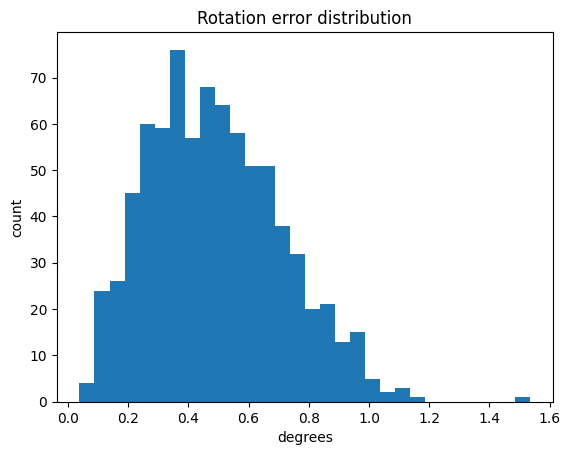

In [19]:
plt.hist(rot_errors, bins=30)
plt.title("Rotation error distribution")
plt.xlabel("degrees")
plt.ylabel("count")
plt.show()

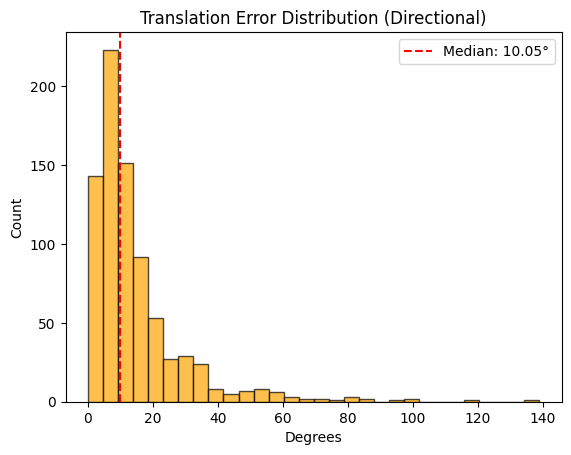

In [20]:
plt.hist(trans_errors, bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.title("Translation Error Distribution (Directional)")
plt.xlabel("Degrees")
plt.ylabel("Count")

median_trans = np.median(trans_errors)
plt.axvline(median_trans, color='red', linestyle='dashed', linewidth=1.5,
            label=f'Median: {median_trans:.2f}°')
plt.legend()

plt.show()